# Final Project Report Code

### Understand The Problem & Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
bank = pd.read_csv("bank_marketing_data.csv")
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
#structure of data
bank.info()
bank.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,44923,45211,43354,45211,45211.000000,45211,45211,32191,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,8252,45211
unique,NaN,11,3,3,2,NaN,2,2,2,NaN,12,NaN,NaN,NaN,NaN,3,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,failure,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,4901,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [ ]:
#dep variable
bank["y"].value_counts()

,count
y,
no,39922
yes,5289


In [ ]:
bank["y"].value_counts(normalize=True)

,proportion
y,
no,0.883015
yes,0.116985


In [ ]:
#quantitative predictors i will use
quant_vars = ["age", "balance", "campaign", "pdays", "previous"]
bank[quant_vars].describe()

,age,balance,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,2.763841,40.197828,0.580323
std,10.618762,3044.765829,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,63.000000,871.000000,275.000000


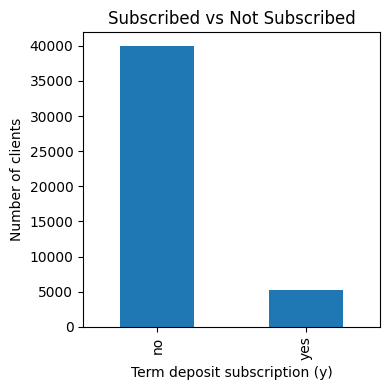

In [ ]:
#Subscribed vs Not Plot
fig, ax = plt.subplots(figsize=(4,4))
bank["y"].value_counts().plot(kind="bar", ax=ax)
ax.set_xlabel("Term deposit subscription (y)")
ax.set_ylabel("Number of clients")
ax.set_title("Subscribed vs Not Subscribed")
plt.tight_layout()
plt.show()

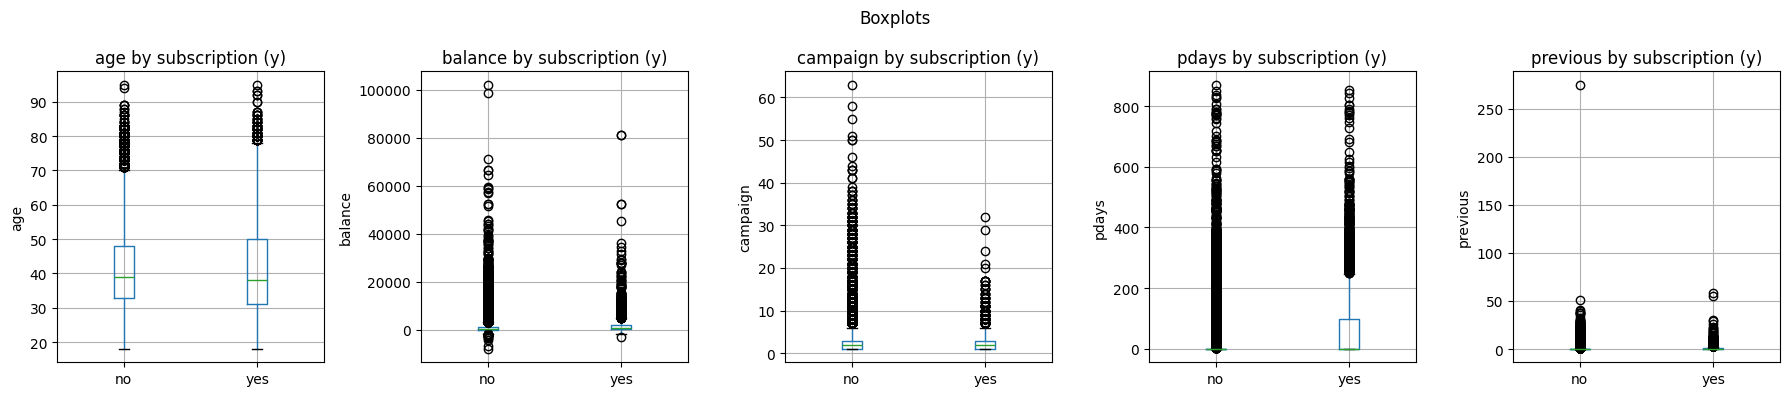

In [ ]:
#Boxplots by class
fig, axes = plt.subplots(1, len(quant_vars), figsize=(18,4))

for ax, col in zip(axes, quant_vars):
    bank.boxplot(column=col, by="y", ax=ax)
    ax.set_title(col + " by subscription (y)")
    ax.set_xlabel("")
    ax.set_ylabel(col)

plt.suptitle("Boxplots")
plt.tight_layout()
plt.show()

In [ ]:
#Correlation between quant vars
bank["y_binary"] = np.where(bank["y"] == "yes", 1, 0)

corr_vars = quant_vars + ["y_binary"]
corr_matrix = bank[corr_vars].corr()

corr_matrix

,age,balance,campaign,pdays,previous,y_binary
age,1.000000,0.097783,0.004760,-0.023758,0.001288,0.025155
balance,0.097783,1.000000,-0.014578,0.003435,0.016674,0.052838
campaign,0.004760,-0.014578,1.000000,-0.088628,-0.032855,-0.073172
pdays,-0.023758,0.003435,-0.088628,1.000000,0.454820,0.103621
previous,0.001288,0.016674,-0.032855,0.454820,1.000000,0.093236
y_binary,0.025155,0.052838,-0.073172,0.103621,0.093236,1.000000


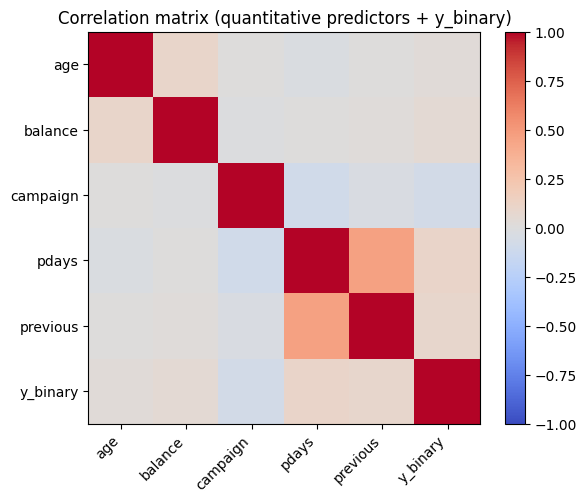

In [ ]:
#Correlation matrix viz
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_vars)))
ax.set_yticks(range(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=45, ha="right")
ax.set_yticklabels(corr_vars)

fig.colorbar(im, ax=ax)
ax.set_title("Correlation matrix (quantitative predictors + y_binary)")
plt.tight_layout()
plt.show()

### KNN Model Specification:



In [ ]:
#Model specified on report

### KNN Model Estimation:

In [ ]:
#Predictors (quantitative): age, balance, campaign, pdays, previous
#Response: y binary as ("yes"/"no")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

bank = pd.read_csv("bank_marketing_data.csv")

predictors = ["age", "balance", "campaign", "pdays", "previous"]
response = "y"

X = bank[predictors].copy()
y = (bank[response] == "yes").astype(int)

#Split data 80 train 20 test
#Stratification preserves the subscriber/non-subscriber class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

#Same cross-validation procedure will be used for model tuning
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)


#View the shape of our split and means
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((36168, 5),
 (9043, 5),
 np.float64(0.11698186241981863),
 np.float64(0.11699657193409267))

In [ ]:
#k values
k_values = range(1, 31)

results_original = []


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    #tune using training data only
    cv_scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    #fit on full training set only to inspect training accuracy
    knn.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, knn.predict(X_train))

    results_original.append(
        (k, train_acc, cv_scores.mean())
    )

results_original_df = pd.DataFrame(
    results_original,
    columns=["k", "train_acc", "cv_accuracy"]
)

results_original_df

,k,train_acc,cv_accuracy
0,1,0.989023,0.816938
1,2,0.908179,0.876659
2,3,0.907764,0.862945
3,4,0.896124,0.879479
4,5,0.895294,0.874779
5,6,0.891700,0.880364
6,7,0.891838,0.878981
7,8,0.889654,0.881470
8,9,0.889709,0.880447
9,10,0.888437,0.881857


In [ ]:
#Best K based on cv accuracy
best_row_orig = results_original_df.sort_values(
    by="cv_accuracy", ascending=False
).iloc[0]

best_k_orig      = int(best_row_orig["k"])
best_train_acc_o = best_row_orig["train_acc"]
best_cv_acc_o  = best_row_orig["cv_accuracy"]

#fit final unscaled KNN using the selected k
knn_orig = KNeighborsClassifier(
    n_neighbors=best_k_orig
)

knn_orig.fit(X_train, y_train)

#test set is evaluated only after k has been selected
y_test_pred_orig = knn_orig.predict(X_test)
best_test_acc_o = accuracy_score(
    y_test,
    y_test_pred_orig
)

best_k_orig, best_train_acc_o, best_cv_acc_o, best_test_acc_o

(30,
 np.float64(0.8836817075868171),
 np.float64(0.8827692562438745),
 0.8838880902355413)

In [ ]:
#With Normalized Data:
#Used minmax scaling
def make_knn_pipeline(k):
    return Pipeline([
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

In [ ]:
#Print k table with train and CV accs
results_norm = []

for k in k_values:
    knn_pipeline = make_knn_pipeline(k)

    #cross-validation on training data only
    cv_scores = cross_val_score(
        knn_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    #fit on full training data to inspect training accuracy
    knn_pipeline.fit(X_train, y_train)
    train_acc = accuracy_score(
        y_train,
        knn_pipeline.predict(X_train)
    )

    results_norm.append(
        (k, train_acc, cv_scores.mean())
    )

results_norm_df = pd.DataFrame(results_norm,
                               columns=["k", "train_acc", "cv_accuracy"])
results_norm_df


,k,train_acc,cv_accuracy
0,1,0.989051,0.815058
1,2,0.908566,0.875276
2,3,0.908123,0.862724
3,4,0.896677,0.880032
4,5,0.895985,0.874364
5,6,0.892861,0.880751
6,7,0.892999,0.878594
7,8,0.891506,0.881857
8,9,0.891257,0.880419
9,10,0.890649,0.882742


In [ ]:
#best normalized K based on cross-validation accuracy
best_row_norm = results_norm_df.sort_values(
    by="cv_accuracy",
    ascending=False
).iloc[0]

best_k_norm = int(best_row_norm["k"])
best_train_acc_n = best_row_norm["train_acc"]
best_cv_acc_n = best_row_norm["cv_accuracy"]

#fit final normalized KNN
knn_norm = make_knn_pipeline(best_k_norm)
knn_norm.fit(X_train, y_train)

#evaluate untouched test set once
y_test_pred_norm = knn_norm.predict(X_test)
best_test_acc_n = accuracy_score(
    y_test,
    y_test_pred_norm
)

print(best_k_norm)
print(best_train_acc_n)
print(best_cv_acc_n)
print(best_test_acc_n)

24
0.8865571776155717
0.8831286854122702
0.8834457591507243


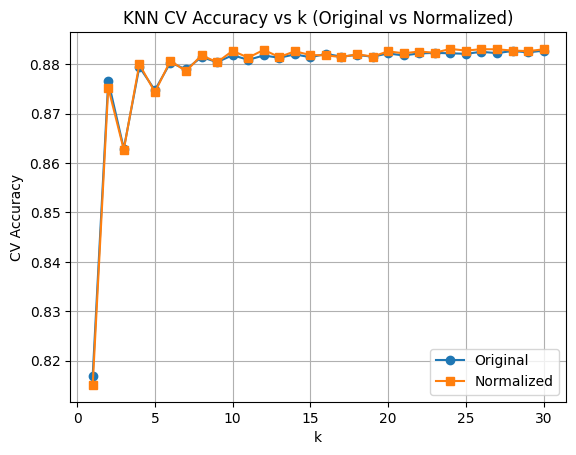

In [ ]:
#KNN CV Accuracy Visualization
import matplotlib.pyplot as plt

plt.plot(results_original_df["k"], results_original_df["cv_accuracy"], marker="o", label="Original")
plt.plot(results_norm_df["k"], results_norm_df["cv_accuracy"], marker="s", label="Normalized")
plt.xlabel("k")
plt.ylabel("CV Accuracy")
plt.title("KNN CV Accuracy vs k (Original vs Normalized)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Unscaled KNN:
#k = 30 achieved the highest 5-fold CV accuracy
#training accuracy was approx 0.884, CV accuracy 0.883, and test accuracy 0.884
#the test set was evaluated after k was selected using training set CV

In [ ]:
#Normalized KNN:
#k = 24 achieved the highest 5-fold CV accuracy
#train accuracy was around 0.887, CV accuracy 0.883, and test accuracy 0.883
#min-max scaling performed inside pipeline - scaling parameters are learned within each CV fold before evaluation on the test set

### Decision Tree Model Specification:

In [ ]:
#Model specified on report

### Decision Tree Model Estimation:

In [ ]:
#decision tree - find ideal max_depth with cv and train accuracies
from sklearn.tree import DecisionTreeClassifier

depth_values = range(1, 11)  # depths 1–10
cv_means = []
train_means = []

for d in depth_values:
    tree = DecisionTreeClassifier(
        max_depth=d,
        random_state=0
    )

    #cross-validation uses training data only
    cv_scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    cv_means.append(cv_scores.mean())

    #training accuracy for comparison
    tree.fit(X_train, y_train)
    train_means.append(
        tree.score(X_train, y_train)
    )

results_dt = pd.DataFrame({
    "max_depth": depth_values,
    "cv_accuracy": cv_means,
    "train_accuracy": train_means
})

print(results_dt)


best_idx = np.argmax(results_dt["cv_accuracy"])
best_depth = results_dt.loc[best_idx, "max_depth"]
best_cv_acc = results_dt.loc[best_idx, "cv_accuracy"]
best_train_acc = results_dt.loc[best_idx, "train_accuracy"]

print("Best max_depth:", best_depth)
print("Best CV accuracy:", best_cv_acc)
print("Training accuracy at best depth:", best_train_acc)


   max_depth  cv_accuracy  train_accuracy
0          1     0.883018        0.883018
1          2     0.883018        0.883018
2          3     0.884152        0.884788
3          4     0.884732        0.886336
4          5     0.884566        0.886447
5          6     0.885036        0.887248
6          7     0.882769        0.889488
7          8     0.882216        0.891976
8          9     0.882050        0.894244
9         10     0.880862        0.896538
Best max_depth: 6
Best CV accuracy: 0.8850364507190476
Training accuracy at best depth: 0.887248396372484


In [ ]:
#fit final tree
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=0)
best_tree.fit(X_train, y_train)

train_acc_final = best_tree.score(X_train, y_train)
test_acc_final = best_tree.score(X_test, y_test)

print("Final tree - train accuracy:", train_acc_final)
print("Final tree - test accuracy:", test_acc_final)


Final tree - train accuracy: 0.887248396372484
Final tree - test accuracy: 0.8834457591507243


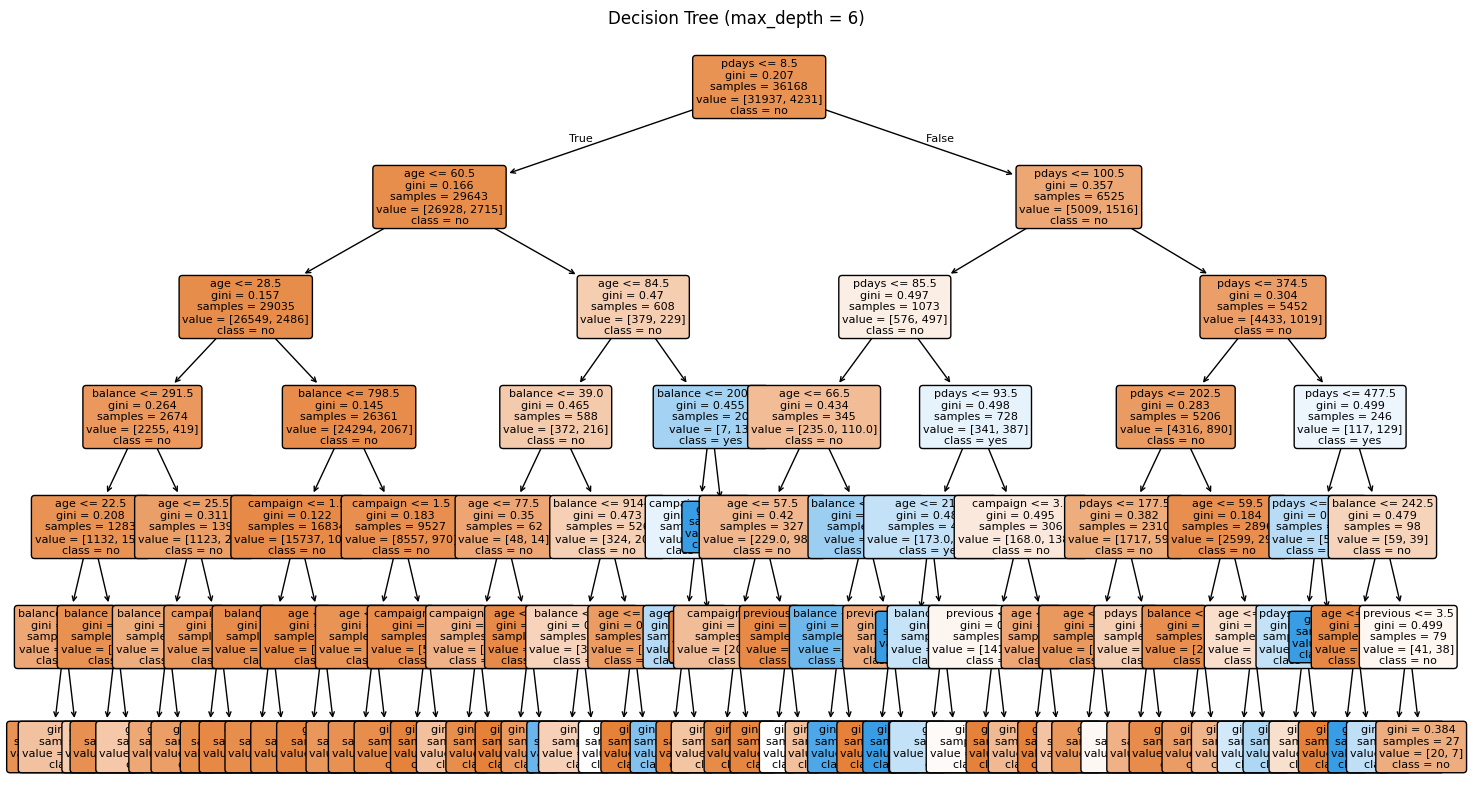

In [ ]:
#decision tree visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    best_tree,
    feature_names=predictors,
    class_names=["no", "yes"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f"Decision Tree (max_depth = {best_depth})")
plt.show()


In [ ]:
#a text version
from sklearn.tree import export_text

tree_rules = export_text(best_tree, feature_names=predictors)
print(tree_rules)


|--- pdays <= 8.50
|   |--- age <= 60.50
|   |   |--- age <= 28.50
|   |   |   |--- balance <= 291.50
|   |   |   |   |--- age <= 22.50
|   |   |   |   |   |--- balance <= 69.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- balance >  69.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  22.50
|   |   |   |   |   |--- balance <= -879.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- balance >  -879.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- balance >  291.50
|   |   |   |   |--- age <= 25.50
|   |   |   |   |   |--- balance <= 424.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- balance >  424.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  25.50
|   |   |   |   |   |--- campaign <= 2.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- campaign >  2.50
|   |   |   |   |   |   |--- class: 0
|   |   |--- age >  28.50
|   |   |   |--- balance <= 798.50
|   |   |   |   |---

pdays       0.675451
age         0.215508
balance     0.067866
campaign    0.030597
previous    0.010578
dtype: float64


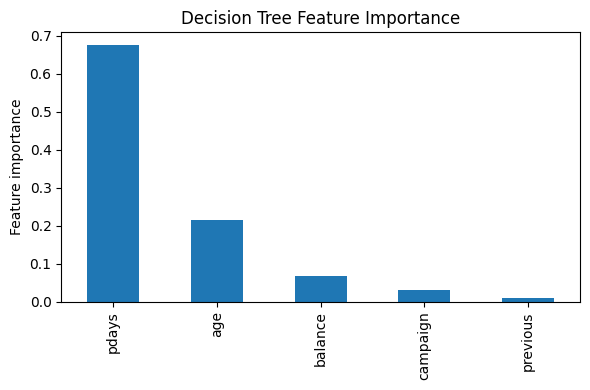

In [ ]:
#Feature Importances
importances = pd.Series(best_tree.feature_importances_, index=predictors)
importances = importances.sort_values(ascending=False)
print(importances)

plt.figure(figsize=(6, 4))
importances.plot(kind="bar")
plt.ylabel("Feature importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
#Decision Tree:
#max_depth = 6 achieved the highest 5-fold CV
#CV accuracy was approx 0.885, training accuracy 0.887, and test accuracy 0.883
#selected tree was fit on the full training set and evaluated once on the test set

In [ ]:
#Feature Importance:
#pdays is the dominant predictor (0.675), followed by age (0.216), balance (0.068), campaign (0.031), and previous (0.011)

In [ ]:
#pdays = -1 represents customers who were never previously contacted.
#therefore, pdays reflects prior contact status and timing rather than being a recency measure
#tree splits involving pdays should not be interpreted as evidence of a "cool-off"

### Bagged Tree Model Specification

In [ ]:
#Model specified on report

### Bagged Tree Model Estimation

In [ ]:
#uses the X_train, X_test, y_train, and y_test created in the KNN modeling setup

In [ ]:
#Bagged tree - list of 10,100,1000 n_estimators - max features = 5
#compute cv scores
#best n_estimators - compute train and test accuracies
from sklearn.ensemble import RandomForestClassifier

n_list = [10, 100, 1000]
results_bag = []

for n in n_list:
    bag_model = RandomForestClassifier(
        n_estimators=n,
        max_features=len(predictors),
        bootstrap=True,
        random_state=0,
        n_jobs=-1
    )

    cv_scores = cross_val_score(
        bag_model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    mean_cv = cv_scores.mean()
    results_bag.append((n, mean_cv))
    print(f"n_estimators = {n}, CV accuracy = {mean_cv:.3f}")

best_n_bag, best_cv_bag = max(results_bag, key=lambda x: x[1])
print("\nBest n_estimators:", best_n_bag, "with CV accuracy:", best_cv_bag)

#final bagged-tree
bag_best = RandomForestClassifier(
    n_estimators=best_n_bag,
    max_features=len(predictors),
    bootstrap=True,
    random_state=0,
    n_jobs=-1
)
bag_best.fit(X_train, y_train)

bag_train_acc = bag_best.score(X_train, y_train)
bag_test_acc  = bag_best.score(X_test, y_test)

print(f"Bagged tree train accuracy: {bag_train_acc:.3f}")
print(f"Bagged tree test accuracy:  {bag_test_acc:.3f}")


n_estimators = 10, CV accuracy = 0.866
n_estimators = 100, CV accuracy = 0.868
n_estimators = 1000, CV accuracy = 0.868

Best n_estimators: 100 with CV accuracy: 0.8682813591944365
Bagged tree train accuracy: 0.992
Bagged tree test accuracy:  0.868


In [ ]:
#n_estimators -> 100 had the highest 5-fold CV accuracy compared to 10 and 1000 trees
#CV accuracy was approx 0.868, training accuracy 0.992, and test accuracy 0.868

### Random Forest Model Specification

In [ ]:
#Model specified on report

### Random Forest Model Estimation

In [ ]:
#Random Forest Model Estimation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

#number of trees as before
n_list = [10, 100, 1000]
results_rf = []

for n in n_list:
    #random subset of predictors at each split (sqrt)
    rf_model = RandomForestClassifier(
        n_estimators=n,
        max_features='sqrt',
        bootstrap=True,
        random_state=0,
        n_jobs=-1
    )

    cv_scores = cross_val_score(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    mean_cv = cv_scores.mean()
    results_rf.append((n, mean_cv))
    print(f"n_estimators = {n}, CV accuracy = {mean_cv:.3f}")

best_n_rf, best_cv_rf = max(results_rf, key=lambda x: x[1])
print("\nBest n_estimators:", best_n_rf, "with CV accuracy:", best_cv_rf)

# fit final rf
rf_best = RandomForestClassifier(
    n_estimators=best_n_rf,
    max_features='sqrt',
    bootstrap=True,
    random_state=0,
    n_jobs=-1
)

rf_best.fit(X_train, y_train)

# performance on train and test sets
y_train_pred_rf = rf_best.predict(X_train)
y_test_pred_rf  = rf_best.predict(X_test)

rf_train_acc = accuracy_score(y_train, y_train_pred_rf)
rf_test_acc  = accuracy_score(y_test, y_test_pred_rf)

print("\nTraining accuracy:", rf_train_acc)
print("Test accuracy:", rf_test_acc)


print("\nConfusion matrix (test set):")

print(confusion_matrix(y_test,y_test_pred_rf))

n_estimators = 10, CV accuracy = 0.862
n_estimators = 100, CV accuracy = 0.860
n_estimators = 1000, CV accuracy = 0.859

Best n_estimators: 10 with CV accuracy: 0.8615075223720605

Training accuracy: 0.9749502322495023
Test accuracy: 0.8574588079177264

Confusion matrix (test set):
[[7613  372]
 [ 917  141]]


In [ ]:
#Random Forest:
#n_estimators = 10 had the highest 5-fold CV accuracy
#CV accuracy was approx 0.862, training accuracy 0.975, and test accuracy 0.857

### Model Assessment

In [ ]:
#knn original data confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

y_test_pred_orig = knn_orig.predict(X_test)

print("KNN (original data)")
print(confusion_matrix(y_test, y_test_pred_orig))
print(classification_report(y_test, y_test_pred_orig, target_names=["no", "yes"]))

#knn normalized data confusion matrix
y_test_pred_norm = knn_norm.predict(X_test)

print("KNN (normalized data)")
print(confusion_matrix(y_test, y_test_pred_norm))
print(classification_report(y_test, y_test_pred_norm, target_names=["no", "yes"]))

KNN (original data)
[[7972   13]
 [1037   21]]
              precision    recall  f1-score   support

          no       0.88      1.00      0.94      7985
         yes       0.62      0.02      0.04      1058

    accuracy                           0.88      9043
   macro avg       0.75      0.51      0.49      9043
weighted avg       0.85      0.88      0.83      9043

KNN (normalized data)
[[7911   74]
 [ 980   78]]
              precision    recall  f1-score   support

          no       0.89      0.99      0.94      7985
         yes       0.51      0.07      0.13      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.53      0.53      9043
weighted avg       0.85      0.88      0.84      9043



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

#Decision Tree confusion matrix
print("Decision Tree (max_depth = {})".format(best_depth))
y_test_pred_tree = best_tree.predict(X_test)

print(confusion_matrix(y_test, y_test_pred_tree))
print(classification_report(y_test, y_test_pred_tree,
                            target_names=["no", "yes"]))


Decision Tree (max_depth = 6)
[[7908   77]
 [ 977   81]]
              precision    recall  f1-score   support

          no       0.89      0.99      0.94      7985
         yes       0.51      0.08      0.13      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.53      0.54      9043
weighted avg       0.85      0.88      0.84      9043



In [ ]:
#Random Forest confusion matrix
y_test_pred_rf  = rf_best.predict(X_test)

print("\nConfusion matrix (test set):")
print(confusion_matrix(y_test, y_test_pred_rf))


Confusion matrix (test set):
[[7613  372]
 [ 917  141]]


In [ ]:
#Bagged Tree Confusion Matrix
y_test_pred_bagged_tree = bag_best.predict(X_test)

print("Confusion matrix (test set):")

print(confusion_matrix(y_test, y_test_pred_bagged_tree))

print("\nClassification report (test set):")

print(classification_report(y_test, y_test_pred_bagged_tree, target_names=["no", "yes"]))

Confusion matrix (test set):
[[7689  296]
 [ 899  159]]

Classification report (test set):
              precision    recall  f1-score   support

          no       0.90      0.96      0.93      7985
         yes       0.35      0.15      0.21      1058

    accuracy                           0.87      9043
   macro avg       0.62      0.56      0.57      9043
weighted avg       0.83      0.87      0.84      9043



### Model Deployment

In [ ]:
#Scoring a new customer

#Define a sample customer:
  #age = 40
  #balance = 1000
  #campaign = 2
  #pdays = -1 (never previously contacted)
  #previous = 0

sample_data = pd.DataFrame([{
    'age': 40,
    'balance': 1000,
    'campaign': 2,
    'pdays': -1,
    'previous': 0
}])

#making sure columns match the order and names used during training
sample_data = sample_data[predictors]

#make prediction using the selected decision tree
predicted_class = best_tree.predict(sample_data)

#mapping numerical prediction back to 'yes' or 'no'
predicted_label = "yes" if predicted_class[0] == 1 else "no"

#estimated probability of subscription
predicted_probability = best_tree.predict_proba(sample_data)[0, 1]

print("Sample Data:")
print(sample_data.to_string(index=False))

print(f"\nPredicted term deposit subscription: {predicted_label}")
print(f"Model-estimated probability of subscription: {predicted_probability:.3f}")

Sample Data:
 age  balance  campaign  pdays  previous
  40     1000         2     -1         0

Predicted term deposit subscription: no

Predicted term deposit subscription: no
Predicted probability of subscription: 0.042
